Connected to Python 3.13.13

In [ ]:
# The dataset gives us electronics sales data at Amazon. 

# It contains user ratings for various electronics items sold, along with category of each item and time of sell.

# The dataset is available at https://www.kaggle.com/datasets/edusanketdk/electronics

# Importing the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
# Importing the dataset
dataset= pd.read_csv('electronics.csv')



In [ ]:
# List the first five rows
dataset.head()



,item_id,user_id,rating,timestamp,model_attr,category,brand,year,user_attr,split
0,0,0,5.0,1999-06-13,Female,Portable Audio & Video,NaN,1999,NaN,0
1,0,1,5.0,1999-06-14,Female,Portable Audio & Video,NaN,1999,NaN,0
2,0,2,3.0,1999-06-17,Female,Portable Audio & Video,NaN,1999,NaN,0
3,0,3,1.0,1999-07-01,Female,Portable Audio & Video,NaN,1999,NaN,0
4,0,4,2.0,1999-07-06,Female,Portable Audio & Video,NaN,1999,NaN,0


In [ ]:
# List the last 5 rows
dataset.tail()



,item_id,user_id,rating,timestamp,model_attr,category,brand,year,user_attr,split
1292949,9478,1157628,1.0,2018-09-26,Female,Headphones,Etre Jeune,2017,NaN,0
1292950,9435,1157629,5.0,2018-09-26,Female,Computers & Accessories,NaN,2017,NaN,0
1292951,9305,1157630,3.0,2018-09-26,Female,Computers & Accessories,NaN,2016,NaN,0
1292952,9303,1157631,5.0,2018-09-29,Male,Headphones,NaN,2018,NaN,0
1292953,9478,1157632,1.0,2018-10-01,Female,Headphones,Etre Jeune,2017,Female,0


In [ ]:
dataset.size

12929540

In [ ]:
dataset.shape

(1292954, 10)

In [ ]:
dataset.columns

Index(['item_id', 'user_id', 'rating', 'timestamp', 'model_attr', 'category',
       'brand', 'year', 'user_attr', 'split'],
      dtype='str')

In [ ]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1292954 entries, 0 to 1292953
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   item_id     1292954 non-null  int64  
 1   user_id     1292954 non-null  int64  
 2   rating      1292954 non-null  float64
 3   timestamp   1292954 non-null  str    
 4   model_attr  1292954 non-null  str    
 5   category    1292954 non-null  str    
 6   brand       331120 non-null   str    
 7   year        1292954 non-null  int64  
 8   user_attr   174124 non-null   str    
 9   split       1292954 non-null  int64  
dtypes: float64(1), int64(4), str(5)
memory usage: 98.6 MB


In [ ]:
from datetime import datetime

In [ ]:
pd.to_datetime(dataset['timestamp'])

0         1999-06-13
1         1999-06-14
2         1999-06-17
3         1999-07-01
4         1999-07-06
             ...    
1292949   2018-09-26
1292950   2018-09-26
1292951   2018-09-26
1292952   2018-09-29
1292953   2018-10-01
Name: timestamp, Length: 1292954, dtype: datetime64[us]

In [ ]:
dataset.columns= dataset.columns.str.lower().str.strip()
dataset.columns



Index(['item_id', 'user_id', 'rating', 'timestamp', 'model_attr', 'category',
       'brand', 'year', 'user_attr', 'split'],
      dtype='str')

In [ ]:
dataset= dataset.drop("split", axis=1)
dataset.columns



Index(['item_id', 'user_id', 'rating', 'timestamp', 'model_attr', 'category',
       'brand', 'year', 'user_attr'],
      dtype='str')

In [ ]:
dataset.isnull().sum()

item_id             0
user_id             0
rating              0
timestamp           0
model_attr          0
category            0
brand          961834
year                0
user_attr     1118830
dtype: int64

In [ ]:
dataset["brand"]= dataset["brand"].fillna("Unknown")
dataset["user_attr"]= dataset["user_attr"].fillna("Unknown")
dataset.isnull().sum()



item_id       0
user_id       0
rating        0
timestamp     0
model_attr    0
category      0
brand         0
year          0
user_attr     0
dtype: int64

In [ ]:
dataset.duplicated().sum()

np.int64(0)

In [ ]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1292954 entries, 0 to 1292953
Data columns (total 9 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   item_id     1292954 non-null  int64  
 1   user_id     1292954 non-null  int64  
 2   rating      1292954 non-null  float64
 3   timestamp   1292954 non-null  str    
 4   model_attr  1292954 non-null  str    
 5   category    1292954 non-null  str    
 6   brand       1292954 non-null  str    
 7   year        1292954 non-null  int64  
 8   user_attr   1292954 non-null  str    
dtypes: float64(1), int64(3), str(5)
memory usage: 88.8 MB


In [ ]:
dataset["timestamp"]= pd.to_datetime(dataset["timestamp"])
dataset.info()



<class 'pandas.DataFrame'>
RangeIndex: 1292954 entries, 0 to 1292953
Data columns (total 9 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   item_id     1292954 non-null  int64         
 1   user_id     1292954 non-null  int64         
 2   rating      1292954 non-null  float64       
 3   timestamp   1292954 non-null  datetime64[us]
 4   model_attr  1292954 non-null  str           
 5   category    1292954 non-null  str           
 6   brand       1292954 non-null  str           
 7   year        1292954 non-null  int64         
 8   user_attr   1292954 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(3), str(4)
memory usage: 88.8 MB


In [ ]:
dataset["rating"].describe()

count    1.292954e+06
mean     4.051482e+00
std      1.379732e+00
min      1.000000e+00
25%      4.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

In [ ]:
dataset = dataset[(dataset["rating"] >= 1) & (dataset["rating"] <= 5)]

In [ ]:
dataset["rating"] = pd.to_numeric(dataset["rating"])

In [ ]:
dataset["category"].unique()

<StringArray>
[ 'Portable Audio & Video', 'Computers & Accessories',
              'Headphones',          'Camera & Photo',
      'Television & Video',              'Home Audio',
  'Accessories & Supplies',   'Car Electronics & GPS',
 'Security & Surveillance',     'Wearable Technology']
Length: 10, dtype: str

In [ ]:
dataset["brand"].unique()

<StringArray>
[     'Unknown',           'HP',      'Philips',     'Polaroid',
    'Panasonic',          'JVC',     'Fujifilm',        'Nikon',
        'Kodak',         'Sony',        'Canon',   'Kensington',
         'Pyle',      'Olympus',      'Toshiba',     'Logitech',
   'Etre Jeune',      'Linksys',      'Vivitar',   'Sennheiser',
        'Apple',      'Samsung',       'EldHus',         'Bose',
       'Archos',       'Garmin',        'Jabra',    'Gary Fong',
    'ViewSonic',       'Savage',       'Uniden',        'ebasy',
      'Generic',         'JLAB',   'Skullcandy',   'TaoTronics',
       'Neewer',   'Koolertron',   'DURAGADGET',        'iRULU',
       'Tiamat',      'DBPOWER',       'Fintie',        'Plemo',
       'EINCAR', 'Cooper Cases',          'LSS',         'Mpow',
     'XShields',        'IRULU',       'Funlux']
Length: 51, dtype: str

In [ ]:
dataset["model_attr"].unique()

<StringArray>
['Female', 'Female&Male', 'Male']
Length: 3, dtype: str

In [ ]:
dataset["user_attr"].unique()

<StringArray>
['Unknown', 'Female', 'Male']
Length: 3, dtype: str

In [ ]:
dataset= dataset.reset_index(drop=True)

In [ ]:
dataset.shape

(1292954, 9)

In [ ]:
dataset["month"] = dataset["timestamp"].dt.month
dataset["month_name"] = dataset["timestamp"].dt.month_name() 
dataset["year"] = dataset["timestamp"].dt.year 



In [ ]:
dataset.columns

Index(['item_id', 'user_id', 'rating', 'timestamp', 'model_attr', 'category',
       'brand', 'year', 'user_attr', 'month', 'month_name'],
      dtype='str')

In [ ]:
dataset.to_csv("Electronics_Cleaned.csv", index=True)

In [ ]:
plt.figure(figsize=(8,5))
sns.set_style("whitegrid")



<Figure size 800x500 with 0 Axes>

In [ ]:
# Exploratory Data Analysis (EDA)

In [ ]:
## What is the overall average rating of products? 
overall_avg_rating = round(dataset['rating'].mean(),2)
overall_avg_rating



np.float64(4.05)

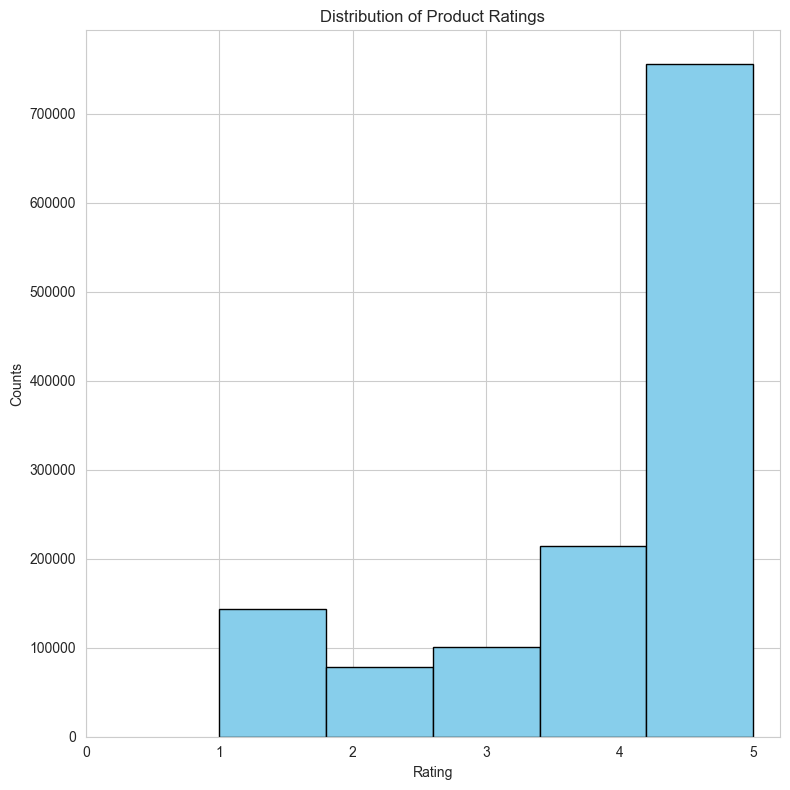

In [ ]:
# Visualize Ratings

plt.figure(figsize=(8,8))

plt.hist(
    dataset["rating"],
    bins=5,
    color="skyblue",
    edgecolor="black"
)

plt.xticks(range(0,6))
plt.xlabel("Rating")
plt.ylabel("Counts")
plt.title("Distribution of Product Ratings")

plt.tight_layout()
plt.show()



In [ ]:
## Buisiness Insight
### The average product rating is 4.05, indicating high customer satisfaction, with most ratings concentrated between 4 and 5.



In [ ]:
dataset["category"].value_counts()

category
Headphones                 359334
Computers & Accessories    322938
Camera & Photo             192573
Accessories & Supplies     158598
Portable Audio & Video     143370
Car Electronics & GPS       33070
Television & Video          32057
Home Audio                  24193
Wearable Technology         16015
Security & Surveillance     10806
Name: count, dtype: int64

In [ ]:
# Which categories receive the highest and lowest ratings? 

mean_rating_by_category = dataset.groupby("category")["rating"].mean().sort_values()
print("Mean Rating By Category", mean_rating_by_category)

highest_rated_category = mean_rating_by_category.idxmax()
Lowest_rated_category = mean_rating_by_category.idxmin()

print("Highest Rated Category: ", highest_rated_category)
print("Lowest Rated Category: ", Lowest_rated_category)



Mean Rating By Category category
Wearable Technology        3.494224
Security & Surveillance    3.770313
Television & Video         3.841626
Headphones                 3.895877
Home Audio                 4.047410
Car Electronics & GPS      4.062897
Computers & Accessories    4.101871
Portable Audio & Video     4.122996
Camera & Photo             4.129795
Accessories & Supplies     4.257784
Name: rating, dtype: float64
Highest Rated Category:  Accessories & Supplies
Lowest Rated Category:  Wearable Technology


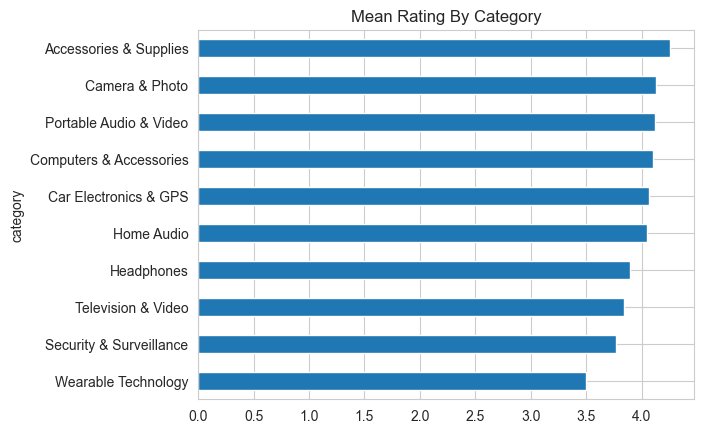

In [ ]:
## Best & Worst category by Ratings

plt.figure()
mean_rating_by_category.plot(kind="barh")
plt.title("Mean Rating By Category")
plt.show()



In [ ]:
#### ⭐ Highest rated category: Accessories & Supplies
#### ⚠ Lowest rated category: Wearable Technology
#### This suggests customers are most satisfied with Accessories & Supplies products and least satisfied with Wearable Technology products.



In [ ]:
dataset["brand"].value_counts()



brand
Unknown         961834
Bose             29222
Logitech         29203
Sony             20360
Mpow             17477
EldHus           16530
Sennheiser       13322
Fujifilm         12245
TaoTronics       12125
Etre Jeune       11753
Pyle             11606
JLAB             10079
Skullcandy       10014
Kodak             8701
Linksys           8288
Jabra             7417
Panasonic         7349
Garmin            7212
Fintie            7212
Samsung           7051
Canon             6959
Neewer            6697
Philips           6658
Nikon             6539
Apple             6027
Polaroid          5926
DBPOWER           4818
Uniden            4701
Olympus           3709
ViewSonic         3426
ebasy             2771
Plemo             2385
HP                2140
LSS               2040
Toshiba           2008
Savage            1749
Tiamat            1738
XShields          1709
JVC               1702
Generic           1606
Gary Fong         1203
iRULU              991
Archos             961
Funlu

In [ ]:
# Which brands have poor customer satisfaction? 

avg_rating_by_brand = dataset.groupby("brand")["rating"].mean().sort_values()
print("Average Rating By Brands: \n", avg_rating_by_brand)

poor_rated_brands = avg_rating_by_brand.head(10)
print("Poor rated brands: ", poor_rated_brands)



Average Rating By Brands: 
 brand
EINCAR          3.069805
Archos          3.257024
IRULU           3.369775
Funlux          3.394036
Generic         3.465131
iRULU           3.474268
JLAB            3.501339
Vivitar         3.511628
Linksys         3.539093
Jabra           3.606579
Pyle            3.646476
DURAGADGET      3.730310
ViewSonic       3.757443
Kodak           3.766234
Skullcandy      3.778211
Polaroid        3.786365
Uniden          3.790045
LSS             3.800980
Philips         3.827426
HP              3.865888
JVC             3.888367
XShields        3.906963
Kensington      3.922330
Toshiba         3.988048
Mpow            3.991017
Samsung         4.002553
Nikon           4.010552
DBPOWER         4.037983
Unknown         4.051156
Koolertron      4.061047
Sennheiser      4.066807
Logitech        4.130843
Olympus         4.148288
Gary Fong       4.150457
Garmin          4.158763
Panasonic       4.164920
Sony            4.170432
TaoTronics      4.186969
EldHus          

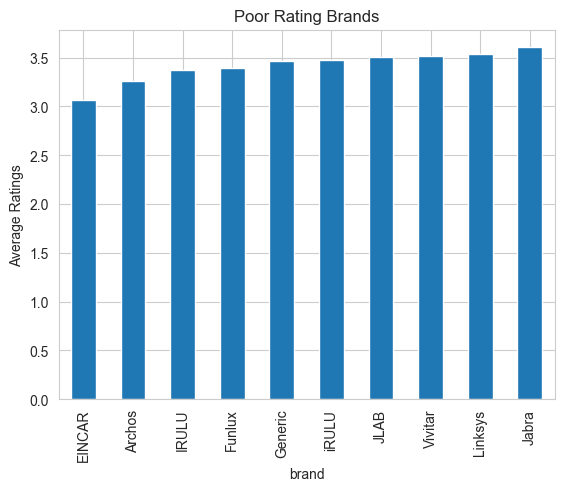

In [ ]:
# bar chart for Poor rated brands

plt.figure()
poor_rated_brands.plot(kind="bar")
plt.title("Poor Rating Brands")
plt.ylabel("Average Ratings")
plt.show()



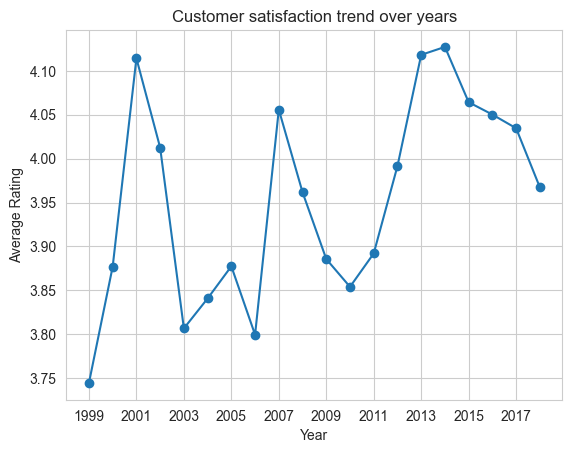

In [ ]:
# Are ratings improving or declining over years? 

yearwise_rating = dataset.groupby("year")["rating"].mean()
plt.figure()
plt.plot(yearwise_rating, marker = "o")
plt.title("Customer satisfaction trend over years")
plt.xticks(range(1999,2018,2))
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.show()



In [ ]:
#### Are ratings improving or declining over years?
#### Customer satisfaction showed fluctuations over the years until 2017. However, average ratings remained above 4 during several periods, with peak satisfaction observed in 2001, 2007, 2013, and 2014.



Number of Ratings by category: 
 category
Security & Surveillance     10806
Wearable Technology         16015
Home Audio                  24193
Television & Video          32057
Car Electronics & GPS       33070
Portable Audio & Video     143370
Accessories & Supplies     158598
Camera & Photo             192573
Computers & Accessories    322938
Headphones                 359334
Name: rating, dtype: int64
Most customer reviewed category:  Headphones


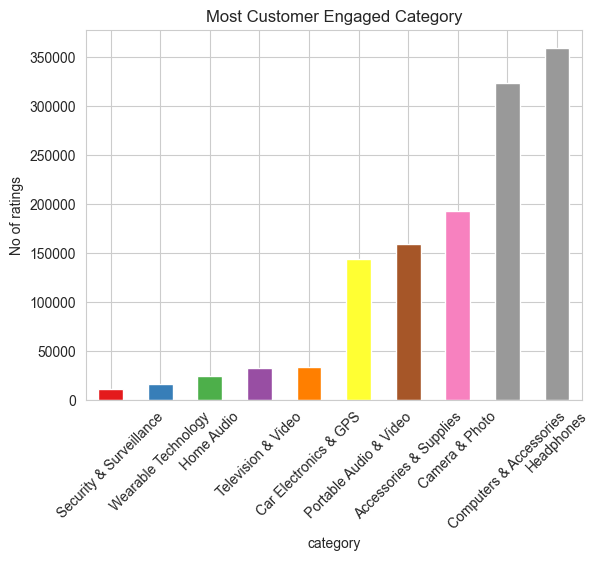

In [ ]:
# 	Which category has the most customer engagement (number of ratings)?

Category_rating_count = dataset.groupby("category")["rating"].count().sort_values()
print("Number of Ratings by category: \n", Category_rating_count)

highest_customer_engagement = Category_rating_count.idxmax()
print("Most customer reviewed category: ", highest_customer_engagement)

plt.figure()
colors= plt.cm.Set1(range(len(Category_rating_count)))
Category_rating_count.plot(kind="bar", color= colors)
plt.ylabel("No of ratings")
plt.xticks(rotation= 45)
plt.title("Most Customer Engaged Category")
plt.show()



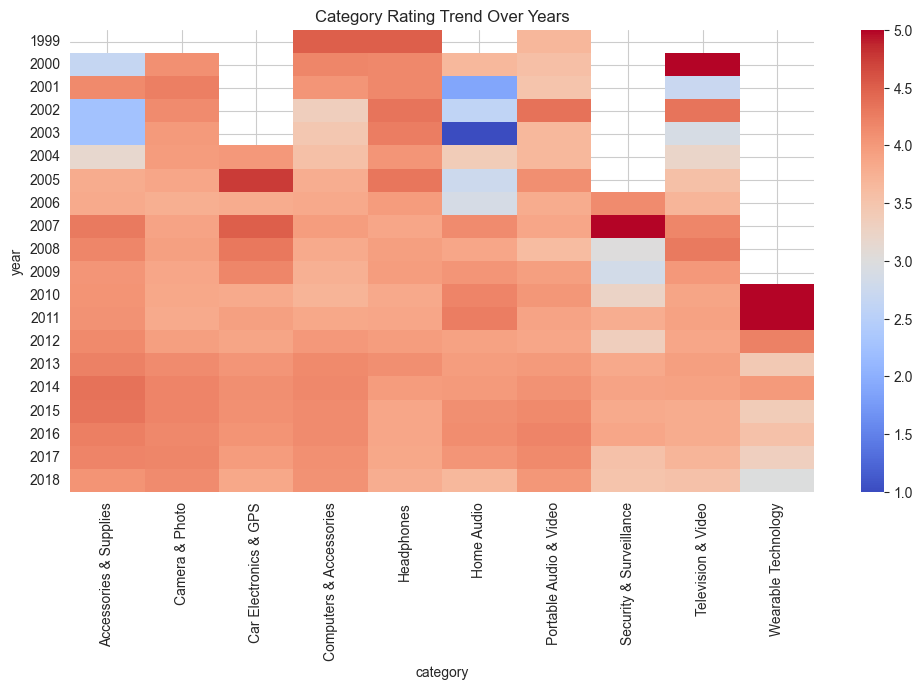

In [ ]:
# 	Which categories are declining over time? 

category_year_trend = dataset.pivot_table(
    values="rating",
    index="year",
    columns="category",
    aggfunc="mean"
)

plt.figure(figsize=(12,6))
sns.heatmap(category_year_trend, cmap="coolwarm")
plt.title("Category Rating Trend Over Years")
plt.show()



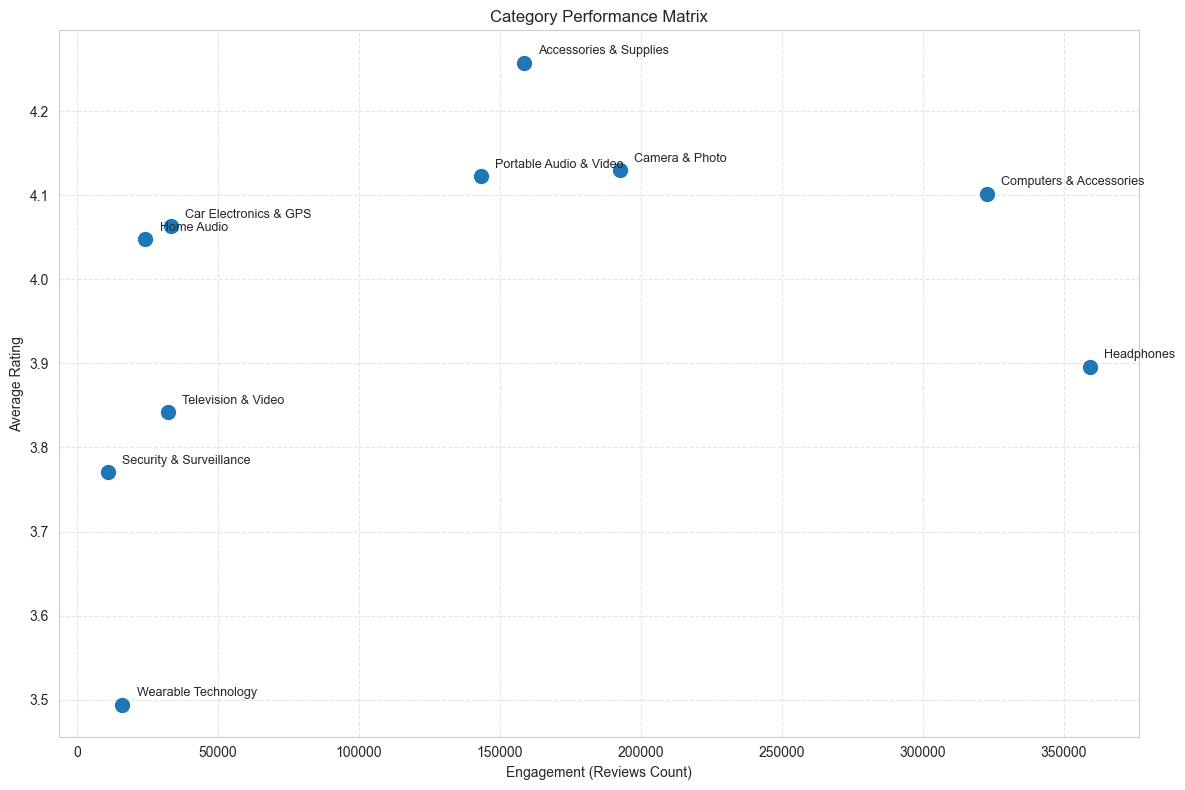

In [ ]:
# 	Which categories should receive more marketing budget? 

category_summary = pd.DataFrame({
    "avg_rating": dataset.groupby("category")["rating"].mean(),
    "engagement": dataset.groupby("category")["rating"].count()
})

category_summary = category_summary.sort_values("avg_rating", ascending=False)
category_summary

plt.figure(figsize=(12,8))

plt.scatter(
    category_summary["engagement"],
    category_summary["avg_rating"],
    s=100
)

plt.xlabel("Engagement (Reviews Count)")
plt.ylabel("Average Rating")
plt.title("Category Performance Matrix")

for i in category_summary.index:
    plt.text(
        category_summary["engagement"][i] + 5000,
        category_summary["avg_rating"][i] + 0.01,
        i,
        fontsize=9
    )

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



In [ ]:
# Business Conclusion

## Category Performance Insights

### Highest rated category: Accessories & Supplies
### Most engaged category: Headphones
### Declining categories: Wearable Technology and Security & Surveillance categories showed declining customer satisfaction over time, indicating potential issues in product quality, innovation, or customer expectations.
### Recommended for marketing: Accessories & Supplies and Camera & Photo show high customer satisfaction but comparatively lower engagement, indicating strong potential for additional marketing investment to increase visibility and sales.



In [ ]:
# Brand Performance Analysis



C:\Users\dhana\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


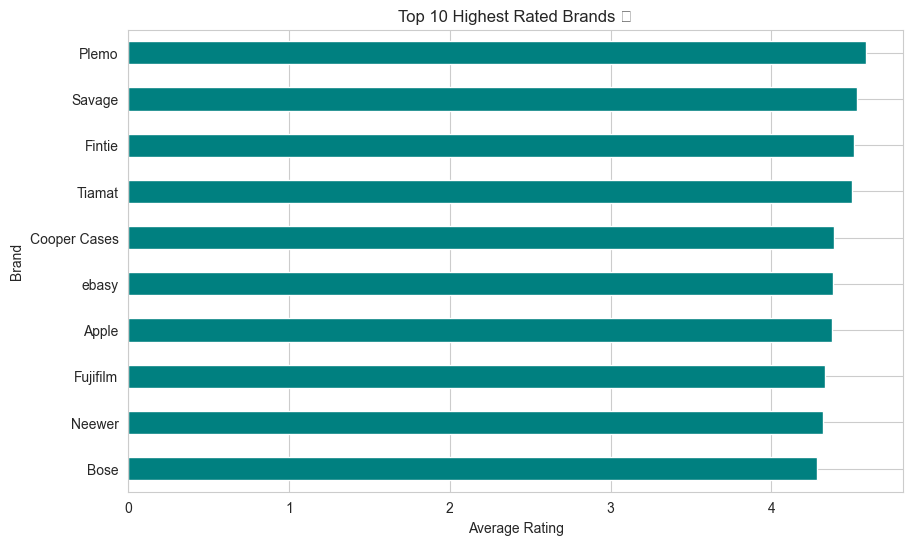

In [ ]:
## Which brands have the highest average ratings?

brand_avg_rating = (
    dataset.groupby("brand")["rating"]
    .mean()
    .sort_values(ascending=False)
)

top10_brands = brand_avg_rating.head(10)
top10_brands

plt.figure(figsize=(10,6))
top10_brands.sort_values().plot(
    kind="barh",
    color="teal"
)

plt.title("Top 10 Highest Rated Brands ⭐")
plt.xlabel("Average Rating")
plt.ylabel("Brand")
plt.show()



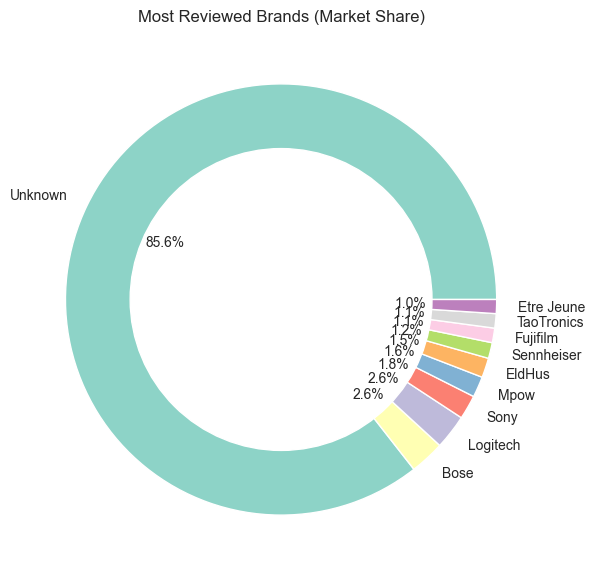

In [ ]:
## Which brands have the most customer reviews?

brand_reviews = (
    dataset.groupby("brand")["rating"]
    .count()
    .sort_values(ascending=False)
)

top10_reviewed = brand_reviews.head(10)
top10_reviewed

plt.figure(figsize=(7,7))

plt.pie(
    top10_reviewed,
    labels=top10_reviewed.index,
    autopct="%1.1f%%",
    colors=plt.cm.Set3.colors
)

centre_circle = plt.Circle((0,0),0.70,fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Most Reviewed Brands (Market Share)")
plt.show()



C:\Users\dhana\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\dhana\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


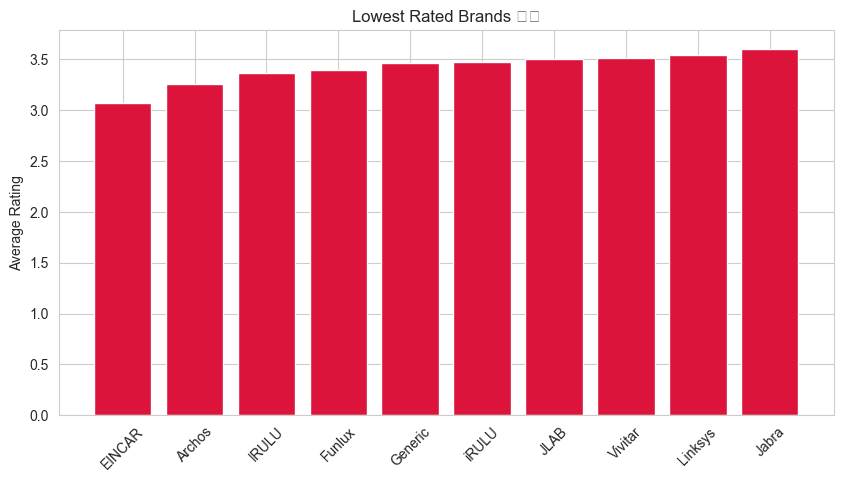

In [ ]:
## Which brands consistently perform poorly?

low_brand_rating = brand_avg_rating.sort_values().head(10)
low_brand_rating

plt.figure(figsize=(10,5))
plt.bar(low_brand_rating.index, low_brand_rating.values,
        color="crimson")

plt.xticks(rotation=45)
plt.title("Lowest Rated Brands ⚠️")
plt.ylabel("Average Rating")
plt.show()



C:\Users\dhana\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


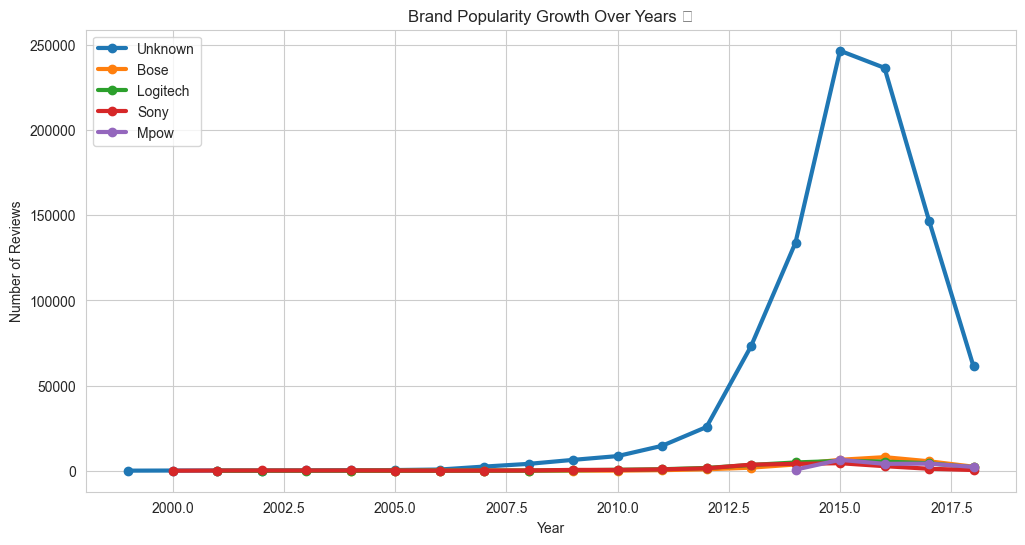

In [ ]:
## Which brands are growing in popularity over time?

brand_year_reviews = dataset.pivot_table(
    values="rating",
    index="year",
    columns="brand",
    aggfunc="count"
)

top_brands = dataset["brand"].value_counts().head(5).index
brand_year_reviews = brand_year_reviews[top_brands]

brand_year_reviews

plt.figure(figsize=(12,6))

for brand in brand_year_reviews.columns:
    plt.plot(
        brand_year_reviews.index,
        brand_year_reviews[brand],
        marker="o",
        linewidth=3,
        label=brand
    )

plt.legend()
plt.title("Brand Popularity Growth Over Years 📈")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.show()



In [ ]:
# Brand Performance Insights

## Highest rated brands: Plemo, Savage, Fintie
## Most popular brands: Other brands
## Poor performing brands: EINCAR, Archos, IRULU
## Growing brands: Brands with upward trend are gaining market popularity. Brands with flat/decline trend may need marketing push.



In [ ]:
# Customer Behavior Analysis

In [ ]:
## Do male and female customers rate differently?

gender_rating = dataset.groupby("user_attr")["rating"].mean()
gender_rating



user_attr
Female     4.218120
Male       4.203251
Unknown    4.026710
Name: rating, dtype: float64

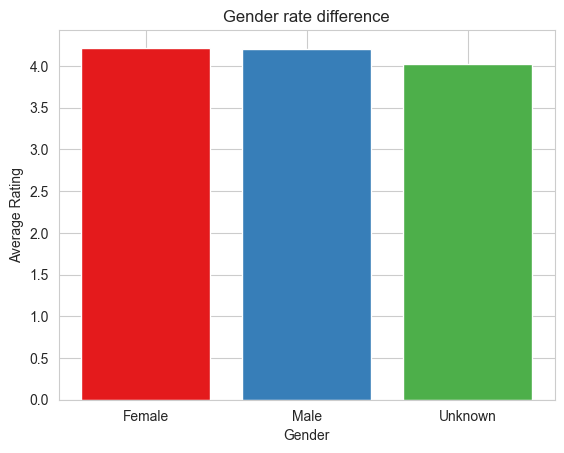

In [ ]:
## Gender rate difference In Chart

plt.figure()
plt.bar(gender_rating.index, gender_rating.values, color= plt.cm.Set1(range(len(gender_rating))))
plt.title("Gender rate difference")
plt.xlabel("Gender")
plt.ylabel("Average Rating")
plt.show()



In [ ]:
## Which gender gives higher ratings?

higher_rated_gender = gender_rating.idxmax()
higher_rated_gender



'Female'

In [ ]:
## Which categories are popular among each gender?

categories_popular_gender = dataset.pivot_table(values="rating", index = "category", columns = "user_attr", aggfunc = "count")
categories_popular_gender



user_attr,Female,Male,Unknown
category,,,
Accessories & Supplies,9610,10922,138066
Camera & Photo,13452,12920,166201
Car Electronics & GPS,1490,2164,29416
Computers & Accessories,22613,22407,277918
Headphones,24298,24566,310470
Home Audio,1284,1770,21139
Portable Audio & Video,9961,8884,124525
Security & Surveillance,812,869,9125
Television & Video,1869,2133,28055


<Figure size 640x480 with 0 Axes>

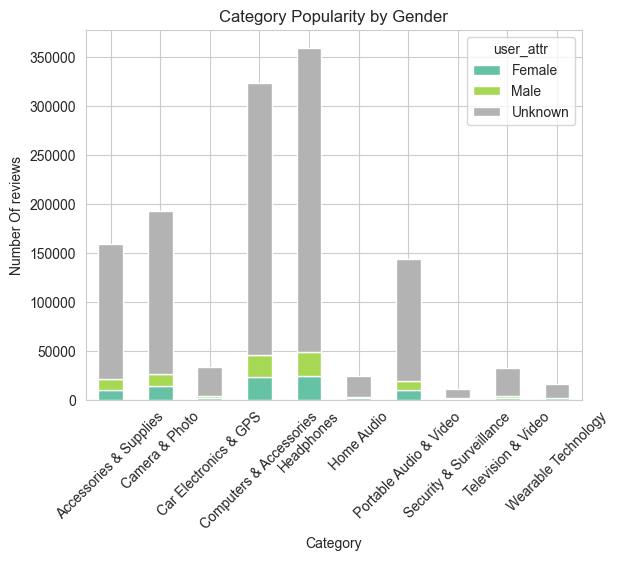

In [ ]:
plt.figure()
categories_popular_gender.plot(kind = "bar", colormap = "Set2", stacked = True)

plt.title("Category Popularity by Gender")
plt.xlabel("Category")
plt.ylabel("Number Of reviews")
plt.xticks(rotation= 45)
plt.show()



<ipython-input-145-3773e56dbfb5>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


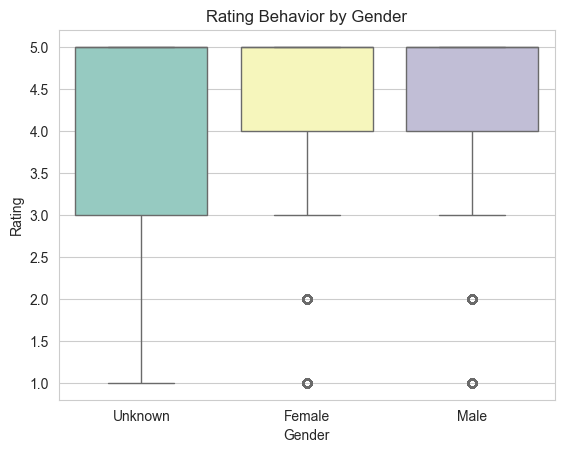

In [ ]:
## Are there differences in rating behavior?

plt.figure()
sns.boxplot(
    x="user_attr",
    y="rating",
    data=dataset,
    palette="Set3"
)

plt.title("Rating Behavior by Gender")
plt.xlabel("Gender")
plt.ylabel("Rating")
plt.show()



In [ ]:
# Customer Behavior Insights

## Gender giving highest ratings: The analysis shows noticeable differences in customer behavior across gender groups. Female customers generally provided slightly higher average ratings compared to male customers, indicating relatively higher satisfaction levels.

## Categories preferred by each gender: In terms of engagement, categories such as Headphones and Computers & Accessories attracted strong participation from both genders, making them the most popular product segments overall. Some categories also demonstrated gender-specific preferences, suggesting opportunities for targeted marketing strategies.

## Rating consistency differences: Rating distributions revealed variations in customer rating behavior between gender groups, with certain groups showing more consistent ratings while others displayed wider variability. These insights can help businesses personalize product recommendations, improve customer targeting, and optimize category-specific marketing campaigns.



In [ ]:
# Product Popularity Analysis

In [ ]:
## Which products receive the most ratings?

most_rated_products = dataset.groupby("item_id")["rating"].count()
most_rated_products



item_id
0        118
1         58
2       3404
3        155
4         11
        ... 
9555       1
9556       4
9557       1
9558       3
9559       1
Name: rating, Length: 9560, dtype: int64

In [ ]:
## Which products receive the most ratings?

most_rated_products = dataset.groupby("item_id")["rating"].count().sort_values(ascending=False)
most_rated_products

top10_most_rated_products = most_rated_products.head(10)
top10_most_rated_products



item_id
7780    28530
2031     9393
1575     8622
2279     6278
2486     5810
2340     5790
5795     5554
1715     5482
1124     5353
1886     5323
Name: rating, dtype: int64

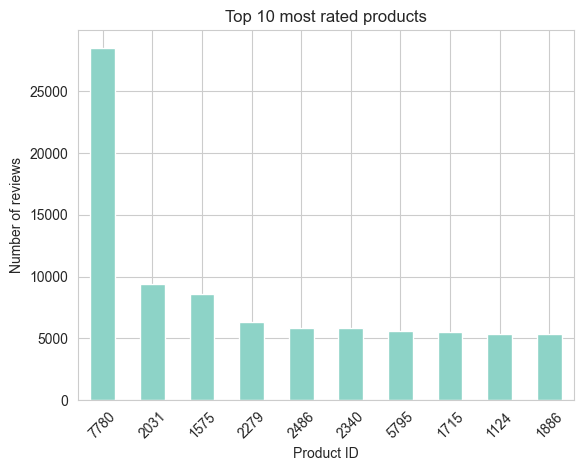

In [ ]:
plt.figure()
top10_most_rated_products.plot(kind = "bar", colormap="Set3")
plt.title("Top 10 most rated products")
plt.xlabel("Product ID")
plt.ylabel("Number of reviews")
plt.xticks(rotation=45)
plt.show()



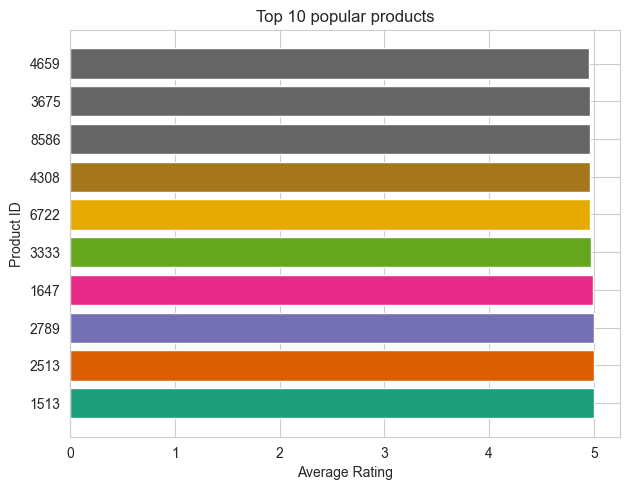

In [ ]:
## Which products receive the highest ratings?

highest_rated_products = dataset.groupby("item_id").agg(avg_rating=("rating","mean"), rating_count =("rating","count"))
highest_rated_popular_products = highest_rated_products[highest_rated_products["rating_count"]>=20]
top10_highest_rated_products = highest_rated_popular_products.sort_values("avg_rating",ascending=False).head(10)

plt.figure()
plt.barh(
    top10_highest_rated_products.index.astype(str),
    top10_highest_rated_products["avg_rating"],
    color=plt.cm.Dark2(range(10))
)
plt.xlabel("Average Rating")
plt.ylabel("Product ID")

plt.tight_layout()
plt.title("Top 10 popular products")
plt.show()



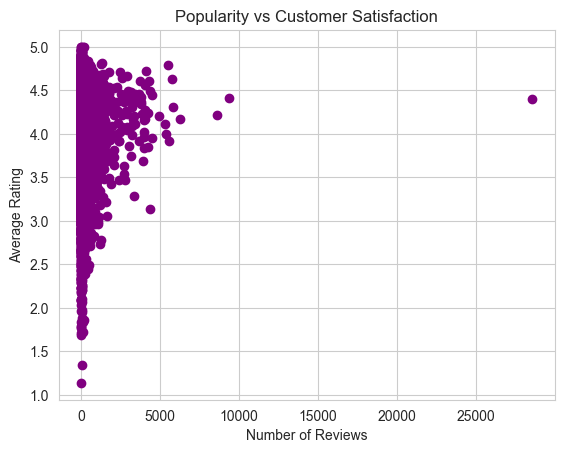

In [ ]:
# Are popular products also highly rated?

plt.figure()
plt.scatter(highest_rated_popular_products["rating_count"],highest_rated_popular_products["avg_rating"], color= "purple")
plt.xlabel("Number of Reviews")
plt.ylabel("Average Rating")
plt.title("Popularity vs Customer Satisfaction")

plt.show()



In [ ]:
# Which products need improvement?

problem_products = highest_rated_popular_products[
    (highest_rated_popular_products["rating_count"] >= 30) &
    (highest_rated_popular_products["avg_rating"] <= 3)
].sort_values("avg_rating")

problem_products.head(10)



,avg_rating,rating_count
item_id,,
1449,1.341463,41
2461,1.723881,134
3467,1.837607,117
100,1.858974,156
1327,1.864078,206
3413,1.880952,42
2144,1.954545,44
6617,1.977273,44
2257,2.033333,30


<ipython-input-164-2826cdac52aa>:25: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dhana\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


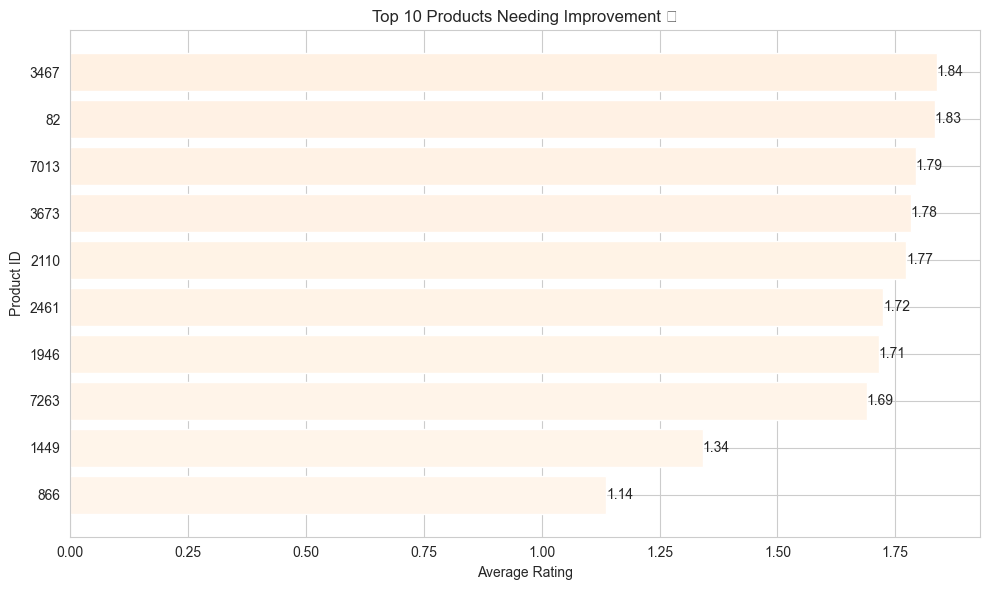

In [ ]:
# Which products need improvement?

problem_products = highest_rated_products[
    highest_rated_products["rating_count"] >= 20
].sort_values("avg_rating")

top_problem_products = problem_products.head(10)

plt.figure(figsize=(10,6))

bars = plt.barh(
    top_problem_products.index.astype(str),
    top_problem_products["avg_rating"],
    color=plt.cm.Oranges(range(10))
)

# Add labels
for i, value in enumerate(top_problem_products["avg_rating"]):
    plt.text(value, i, f"{value:.2f}", va='center')

plt.title("Top 10 Products Needing Improvement 🚨")
plt.xlabel("Average Rating")
plt.ylabel("Product ID")

plt.tight_layout()
plt.show()



In [ ]:
# BUSINESS SUMMARY

## Product Popularity Insights

### ✔ Most reviewed products represent top-selling / high-demand items

### ✔ Highest rated products represent best customer satisfaction

### ✔ Scatter analysis shows:

#### Some products are both popular & highly rated → Promote heavily
#### Some products are popular but poorly rated → Fix quality urgently

### ✔ Products needing improvement:

#### The analysis identified several low-performing products with consistently poor customer ratings despite having sufficient review volume. These products may require quality improvements, feature enhancements, or better customer support strategies.

